# Step 6: Time step and stability

How large can the time step be before the results change, and where does the run become unstable? I ran the baseline setup (WENO tracer and momentum advection, dx = 500 m, dz = 1 m, nu_h = 1e-2 m^2/s) with fixed time steps chosen for advective CFL numbers of 0.2 to 4.0, and compared them with Oceananigans' adaptive time stepping (`simulations/run_step6.jl`).

The advective CFL number is how far the water moves in one time step, measured in grid cells: CFL = u dt / dx + w dt / dz. An explicit scheme computes each new value only from nearby old values. If the water moves further than those nearby cells in one step, the scheme uses information from the wrong place, small errors are amplified every step, and the run eventually blows up. How close to 1 a model can go depends on the time-stepping method and the advection scheme; this model uses a quasi-second-order Adams-Bashforth method (`QuasiAdamsBashforth2`, the default of the hydrostatic model in this version).

I load the libraries and set the parameters. The fixed time steps were set from the baseline's largest value of u/dx + w/dz, 0.0073083 per second, reached about 36 minutes in; dt = CFL / 0.0073083. In this test the vertical part dominates: w/dz was 0.0058 and u/dx 0.0015 at that moment.

In [1]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mixing_tools import (DELTA_B, DEPTH, LENGTH, load_run, rpe_series, buoyancy_variance, front_positions,
                          front_speed, rpe_rate_at)

MAX_RATE = 0.0073083088                                 # largest u/dx + w/dz in the baseline (1/s)
FIXED = {0.2: "step6_fixed_cfl0p2", 0.5: "step6_fixed_cfl0p5", 1.0: "step6_fixed_cfl1p0", 1.5: "step6_fixed_cfl1p5",
         2.0: "step6_fixed_cfl2p0", 2.5: "step6_fixed_cfl2p5", 3.0: "step6_fixed_cfl3p0", 4.0: "step6_fixed_cfl4p0"}
NAN_ONLY = {2.0: "step6_fixed_cfl2p0_nan_only", 2.5: "step6_fixed_cfl2p5_nan_only"}
ADAPTIVE = {0.2: "step2_baseline_weno", 0.5: "step6_adaptive_cfl0p5"}
FIT_START, FIT_END = 3 * 3600, 15 * 3600
FIG_DIR = "../figures"
DATA_DIR = "../data"

Every run, its status and how far it got. These runs were checked at every single time step: the run stops cleanly if anything is NaN, if b goes more than one buoyancy difference outside its starting range, or if a speed exceeds 10 m/s. For CFL 2.0 and 2.5 I also repeated the run with the range check switched off (only NaN or the speed limit stops it), to separate 'badly wrong' from 'blowing up'.

In [2]:
rows = []
def summarize(kind, cfl_target, name):
    ds, log, info = load_run(name)
    row = {"kind": kind, "target_cfl": cfl_target, "run": name, "status": info["status"],
           "time_stepping": info["time_stepping"], "iterations": int(info["iterations"]),
           "model_hours": float(info["model_time_s"]) / 3600, "max_measured_cfl": log["advective_cfl"].max(),
           "median_dt_s": log["dt_s"].median(), "overshoot": max(log["b_max"].max() - DELTA_B, 0) / DELTA_B,
           "undershoot": max(-log["b_min"].min(), 0) / DELTA_B, "max_speed_m_s": log["u_max_abs"].max(),
           "wall_time_s": float(info["wall_time_s"])}
    if info["status"] == "completed":
        times = ds.time.values
        rpe = rpe_series(ds)
        variance = buoyancy_variance(ds)
        right, left = front_positions(ds)
        row.update({"rpe_change_17h": (rpe[-1] - rpe[0]) / rpe[0], "rpe_smallest_step": np.min(np.diff(rpe)) / rpe[0],
                    "variance_change_17h": (variance[-1] - variance[0]) / variance[0],
                    "front_speed_m_s": front_speed(times, right, FIT_START, FIT_END)})
    rows.append(row)

for cfl, name in ADAPTIVE.items():
    summarize("adaptive", cfl, name)
for cfl, name in FIXED.items():
    summarize("fixed", cfl, name)
for cfl, name in NAN_ONLY.items():
    summarize("fixed, NaN check only", cfl, name)
table = pd.DataFrame(rows)
table.to_csv(os.path.join(DATA_DIR, "step6_time_step.csv"), index=False)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 70)
print(table[["kind", "target_cfl", "median_dt_s", "max_measured_cfl", "iterations", "model_hours", "overshoot",
             "max_speed_m_s", "rpe_change_17h", "variance_change_17h", "front_speed_m_s"]].to_string(index=False))
print()
for row in rows:
    print(f"{row['kind']:22s} CFL {row['target_cfl']:3.1f}: {row['status']}")

                 kind  target_cfl  median_dt_s  max_measured_cfl  iterations  model_hours  overshoot  max_speed_m_s  rpe_change_17h  variance_change_17h  front_speed_m_s
             adaptive         0.2    37.771931          0.256627        1907    17.000000   0.000211       0.755725        0.000035            -0.185590         0.479298
             adaptive         0.5    90.404371          0.769382        1024    17.000000   0.000215       0.755650        0.000035            -0.184345         0.479298
                fixed         0.2    27.366112          0.201081        2244    17.000000   0.000212       0.755818        0.000036            -0.185814         0.479298
                fixed         0.5    68.415281          0.505355         918    17.000000   0.000211       0.755410        0.000035            -0.185348         0.479298
                fixed         1.0   136.830562          1.038162         510    17.000000   0.000225       0.754653        0.000037            -0.1872

Overshoots against time for the fixed time steps (log scale): how far b went outside its starting range, as a fraction of the buoyancy difference. A clean WENO run stays near 1e-4.

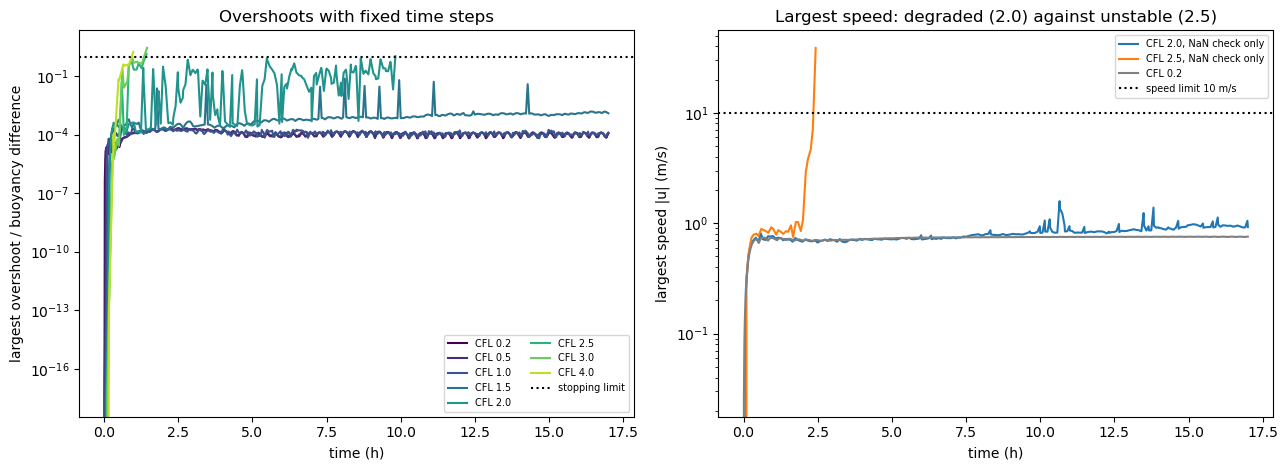

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
shades = plt.cm.viridis(np.linspace(0, 0.9, len(FIXED)))
for (cfl, name), shade in zip(FIXED.items(), shades):
    ds, log, info = load_run(name)
    over = np.maximum(log["b_max"] - DELTA_B, np.maximum(-log["b_min"], 0)) / DELTA_B
    axes[0].semilogy(log["time_s"] / 3600, over, color=shade, label=f"CFL {cfl}")
axes[0].axhline(1.0, color="k", ls=":", label="stopping limit")
axes[0].set_xlabel("time (h)")
axes[0].set_ylabel("largest overshoot / buoyancy difference")
axes[0].set_title("Overshoots with fixed time steps")
axes[0].legend(fontsize=7, ncol=2)
for cfl, name in NAN_ONLY.items():
    ds, log, info = load_run(name)
    axes[1].semilogy(log["time_s"] / 3600, log["u_max_abs"], label=f"CFL {cfl}, NaN check only")
ds, log, info = load_run(FIXED[0.2])
axes[1].semilogy(log["time_s"] / 3600, log["u_max_abs"], color="0.5", label="CFL 0.2")
axes[1].axhline(10.0, color="k", ls=":", label="speed limit 10 m/s")
axes[1].set_xlabel("time (h)")
axes[1].set_ylabel("largest speed |u| (m/s)")
axes[1].set_title("Largest speed: degraded (2.0) against unstable (2.5)")
axes[1].legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_time_step_overshoots_and_speed.png"), dpi=150)
plt.show()

Buoyancy after 17 hours for CFL 0.2, 1.0, 1.5 and 2.0 (the NaN-check-only run), on the same colour scale.

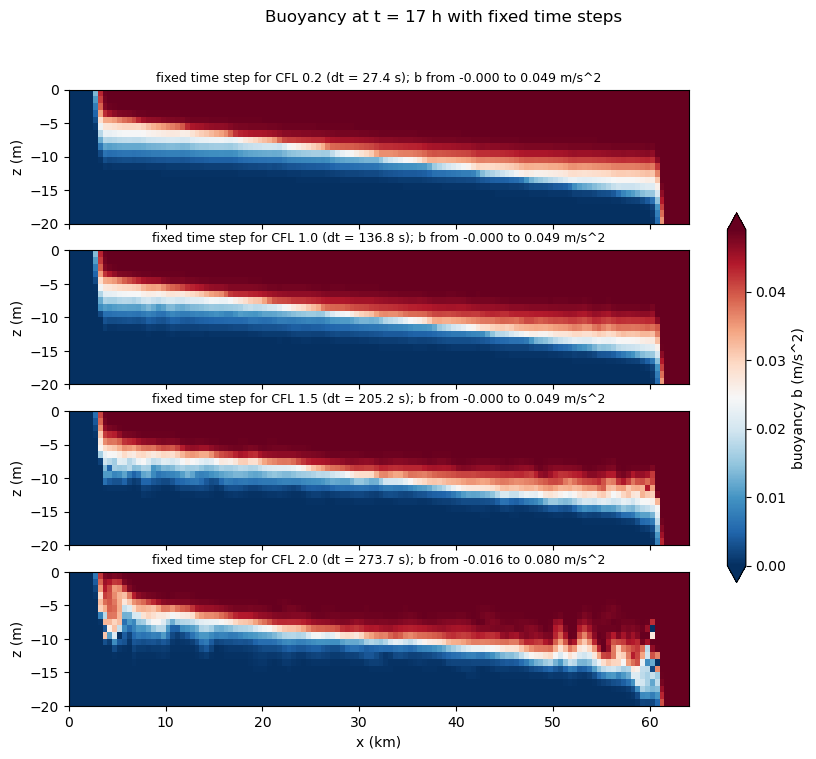

In [4]:
show = [(0.2, FIXED[0.2]), (1.0, FIXED[1.0]), (1.5, FIXED[1.5]), (2.0, NAN_ONLY[2.0])]
fig, axes = plt.subplots(len(show), 1, figsize=(10, 8), sharex=True)
for ax, (cfl, name) in zip(axes, show):
    ds, log, info = load_run(name)
    snapshot = ds["b"].sel(time=17 * 3600, method="nearest")
    mesh = ax.pcolormesh(ds.x_caa / 1e3, ds.z_aac, snapshot, cmap="RdBu_r", vmin=0, vmax=DELTA_B, shading="nearest")
    ax.set_ylabel("z (m)")
    ax.set_title(f"fixed time step for CFL {cfl} (dt = {cfl / MAX_RATE:.1f} s); b from {float(snapshot.min()):.3f} "
                 f"to {float(snapshot.max()):.3f} m/s^2", fontsize=9)
axes[-1].set_xlabel("x (km)")
fig.colorbar(mesh, ax=axes, label="buoyancy b (m/s^2)", shrink=0.6, extend="both")
fig.suptitle("Buoyancy at t = 17 h with fixed time steps")
fig.savefig(os.path.join(FIG_DIR, "06_time_step_snapshots.png"), dpi=150, bbox_inches="tight")
plt.show()

## Fixed against adaptive time stepping

The `TimeStepWizard` changes the time step every 10 iterations to keep the CFL number near a target, using the velocities at that moment. A fixed time step must be safe for the fastest moment of the whole run, which here is the collapse in the first hour; later the flow is slower and a fixed step wastes iterations. I compare the number of steps and the results.

In [5]:
for target in [0.2, 0.5]:
    adaptive = table[(table["kind"] == "adaptive") & (table["target_cfl"] == target)].iloc[0]
    fixed = table[(table["kind"] == "fixed") & (table["target_cfl"] == target)].iloc[0]
    print(f"CFL target {target}: adaptive {adaptive['iterations']} steps (median dt {adaptive['median_dt_s']:.1f} s, "
          f"largest measured CFL {adaptive['max_measured_cfl']:.3f}, RPE change {adaptive['rpe_change_17h']:.3e}) | "
          f"fixed {fixed['iterations']} steps (dt {fixed['median_dt_s']:.1f} s, largest CFL {fixed['max_measured_cfl']:.3f}, "
          f"RPE change {fixed['rpe_change_17h']:.3e})")

CFL target 0.2: adaptive 1907 steps (median dt 37.8 s, largest measured CFL 0.257, RPE change 3.543e-05) | fixed 2244 steps (dt 27.4 s, largest CFL 0.201, RPE change 3.553e-05)
CFL target 0.5: adaptive 1024 steps (median dt 90.4 s, largest measured CFL 0.769, RPE change 3.491e-05) | fixed 918 steps (dt 68.4 s, largest CFL 0.505, RPE change 3.532e-05)


## Link to my MITgcm blow-up (project 15)

In project 15 the tracer time step was 1 day (the accelerated "asynchronous" time stepping of that tutorial). In the column that blew up, the local vertical CFL number for the tracer step rose from 0.03 to 0.52, and the centred tracer scheme then created temperatures and salinities that were not in the column before; the run ran away within a few steps. Two lessons from this step fit that story. First, the vertical velocity, not the horizontal one, can set the CFL limit when the layers are thin. Second, the safe CFL depends on the scheme: here WENO stayed clean up to about 1, but step 3 showed that the centred scheme makes large overshoots even at CFL 0.2, so a centred scheme with a long time step at a sharp front is the worst combination.